# 🎵 Spotify Hit Predictor — Phase 2: Exploratory Data Analysis

**Dataset:** [The Spotify Hit Predictor Dataset (1960–2019)](https://www.kaggle.com/datasets/theoverman/the-spotify-hit-predictor-dataset)  
**Goal:** Understand what separates a hit from a flop across 6 decades of music.

### Key questions we'll answer:
1. What does the dataset look like? Any missing data or imbalances?
2. Which audio features differ most between hits and flops?
3. How have hit song characteristics changed decade by decade?
4. Which features are most correlated with each other (and with `target`)?
5. What does a "typical hit" look like vs a "typical flop"?

## 0. Setup & Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# ── Styling ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        130,
    'figure.facecolor':  'white',
    'axes.facecolor':    '#fafafa',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'sans-serif',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
})

HIT_COLOR  = '#1DB954'   # Spotify green  → hits
FLOP_COLOR = '#535353'   # Dark gray      → flops
PALETTE    = [HIT_COLOR, FLOP_COLOR]

OUTPUTS = '../outputs/figures'
os.makedirs(OUTPUTS, exist_ok=True)

print('✅  Setup complete')

✅  Setup complete


## 1. Load Data

**Download instructions:**
1. Go to https://www.kaggle.com/datasets/theoverman/the-spotify-hit-predictor-dataset
2. Click **Download** — you'll get a zip with CSVs split by decade
3. Place all CSV files in `data/raw/`
4. Run the cell below — it auto-combines them all

In [3]:
RAW_DIR = '../data/raw/'

# ── Load all decade CSVs and combine ─────────────────────────────────────
csv_files = [f for f in os.listdir(RAW_DIR) if f.endswith('.csv')]
print(f'Found {len(csv_files)} CSV files: {sorted(csv_files)}')

frames = []
for f in sorted(csv_files):
    decade_df = pd.read_csv(os.path.join(RAW_DIR, f))
    # Extract decade from filename e.g. 'dataset-of-60s.csv' → 1960
    for decade_str, decade_year in [('60','1960'),('70','1970'),('80','1980'),
                                     ('90','1990'),('00','2000'),('10','2010')]:
        if decade_str in f:
            decade_df['decade'] = int(decade_year)
            break
    frames.append(decade_df)

df = pd.concat(frames, ignore_index=True)

# Rename target column to is_hit for clarity
df = df.rename(columns={'target': 'is_hit'})

print(f'\n✅  Combined dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Found 6 CSV files: ['dataset-of-00s.csv', 'dataset-of-10s.csv', 'dataset-of-60s.csv', 'dataset-of-70s.csv', 'dataset-of-80s.csv', 'dataset-of-90s.csv']

✅  Combined dataset: 41,106 rows × 20 columns


,track,artist,uri,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,is_hit,decade
0,Lucky Man,Montgomery Gentry,spotify:track:4GiXBCUF7H6YfNQsnBRIzl,0.578,0.471,4,-7.270,1,0.0289,0.368000,0.00000,0.159,0.532,133.061,196707,4,30.88059,13,1,2000
1,On The Hotline,Pretty Ricky,spotify:track:1zyqZONW985Cs4osz9wlsu,0.704,0.854,10,-5.477,0,0.1830,0.018500,0.00000,0.148,0.688,92.988,242587,4,41.51106,10,1,2000
2,Clouds Of Dementia,Candlemass,spotify:track:6cHZf7RbxXCKwEkgAZT4mY,0.162,0.836,9,-3.009,1,0.0473,0.000111,0.00457,0.174,0.300,86.964,338893,4,65.32887,13,0,2000


## 2. Data Overview

In [4]:
# ── Column types & nulls ──────────────────────────────────────────────────
print('=== COLUMNS & DTYPES ===')
print(df.dtypes)

print('\n=== MISSING VALUES ===')
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else '  None — dataset is clean! ✅')

print('\n=== BASIC STATS ===')
df.describe().round(3)

=== COLUMNS & DTYPES ===
track                   str
artist                  str
uri                     str
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
duration_ms           int64
time_signature        int64
chorus_hit          float64
sections              int64
is_hit                int64
decade                int64
dtype: object

=== MISSING VALUES ===
  None — dataset is clean! ✅

=== BASIC STATS ===


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,is_hit,decade
count,41106.000,41106.000,41106.000,41106.000,41106.000,41106.000,41106.000,41106.000,41106.000,41106.000,41106.000,41106.000,41106.000,41106.000,41106.000,41106.0,41106.000
mean,0.540,0.580,5.214,-10.222,0.693,0.073,0.364,0.154,0.202,0.542,119.338,234877.550,3.894,40.106,10.476,0.5,1982.775
std,0.178,0.253,3.535,5.312,0.461,0.086,0.339,0.304,0.173,0.267,29.099,118967.398,0.423,19.006,4.872,0.5,17.491
min,0.000,0.000,0.000,-49.253,0.000,0.000,0.000,0.000,0.013,0.000,0.000,15168.000,0.000,0.000,0.000,0.0,1960.000
25%,0.420,0.396,2.000,-12.816,0.000,0.034,0.039,0.000,0.094,0.330,97.397,172927.750,4.000,27.600,8.000,0.0,1970.000
50%,0.552,0.601,5.000,-9.257,1.000,0.043,0.258,0.000,0.132,0.558,117.565,217907.000,4.000,35.851,10.000,0.5,1980.000
75%,0.669,0.787,8.000,-6.374,1.000,0.070,0.676,0.061,0.261,0.768,136.494,266773.000,4.000,47.626,12.000,1.0,2000.000
max,0.988,1.000,11.000,3.744,1.000,0.960,0.996,1.000,0.999,0.996,241.423,4170227.000,5.000,433.182,169.000,1.0,2010.000


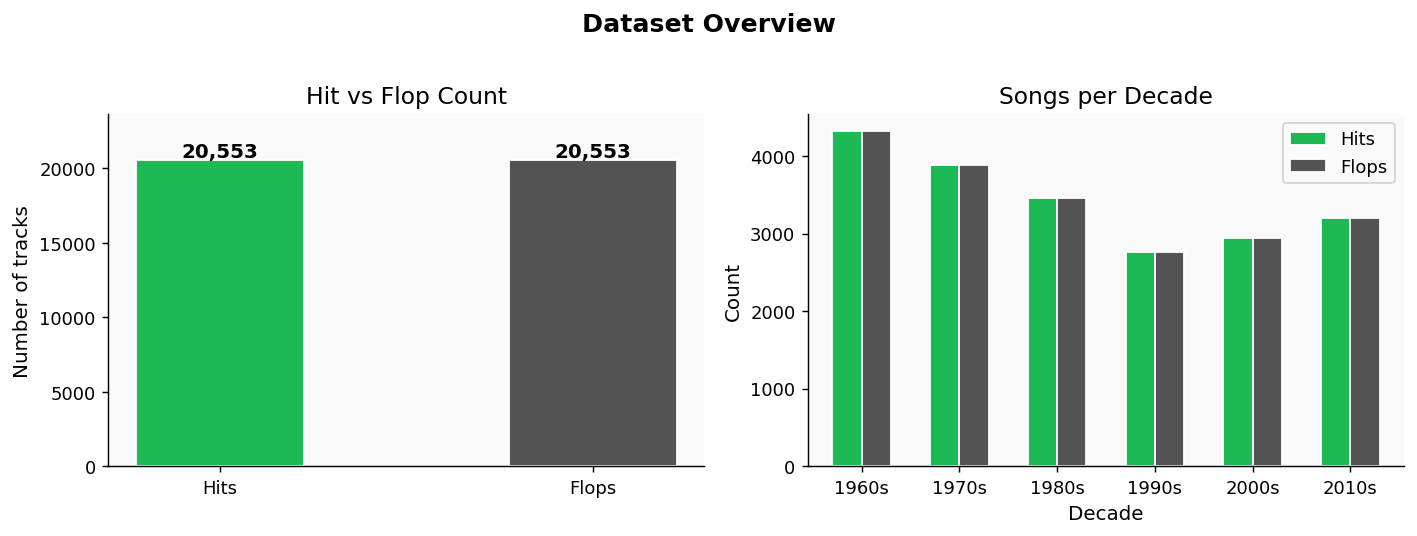


Hits:  20,553 (50.0%)
Flops: 20,553 (50.0%)


In [5]:
# ── Class balance: Hits vs Flops ──────────────────────────────────────────
hit_counts = df['is_hit'].value_counts()
hit_pct    = df['is_hit'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
bars = axes[0].bar(['Hits', 'Flops'], hit_counts.values,
                   color=PALETTE, width=0.45, edgecolor='white')
for bar, val in zip(bars, hit_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Hit vs Flop Count')
axes[0].set_ylabel('Number of tracks')
axes[0].set_ylim(0, hit_counts.max() * 1.15)

# Songs per decade
decade_counts = df.groupby(['decade','is_hit']).size().unstack()
decade_counts.columns = ['Flops','Hits']
decade_counts[['Hits','Flops']].plot(
    kind='bar', ax=axes[1], color=PALETTE,
    edgecolor='white', width=0.6
)
axes[1].set_title('Songs per Decade')
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels([str(d)+'s' for d in decade_counts.index], rotation=0)
axes[1].legend()

plt.suptitle('Dataset Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/01_dataset_overview.png', bbox_inches='tight')
plt.show()

print(f'\nHits:  {hit_counts[1]:,} ({hit_pct:.1f}%)')
print(f'Flops: {hit_counts[0]:,} ({100-hit_pct:.1f}%)')

## 3. Feature Definitions

| Feature | Description | Range |
|---------|-------------|-------|
| `danceability` | How suitable for dancing | 0–1 |
| `energy` | Intensity and activity | 0–1 |
| `valence` | Musical positivity / happiness | 0–1 |
| `tempo` | Beats per minute | ~50–220 |
| `loudness` | Overall loudness | –60 to 0 dB |
| `speechiness` | Presence of spoken words | 0–1 |
| `acousticness` | Whether acoustic | 0–1 |
| `instrumentalness` | Predicts no vocals | 0–1 |
| `liveness` | Audience detected | 0–1 |
| `duration_ms` | Track length in milliseconds | — |
| `chorus_hit` | Estimated time of first chorus | seconds |
| `sections` | Number of musical sections | count |
| `key` | Musical key (0=C … 11=B) | 0–11 |
| `mode` | Major (1) or Minor (0) | 0–1 |
| `time_signature` | Beats per measure | 3–7 |
| `is_hit` | **Target: 1=Hit, 0=Flop** | 0–1 |

## 4. Hits vs Flops — Feature Distributions

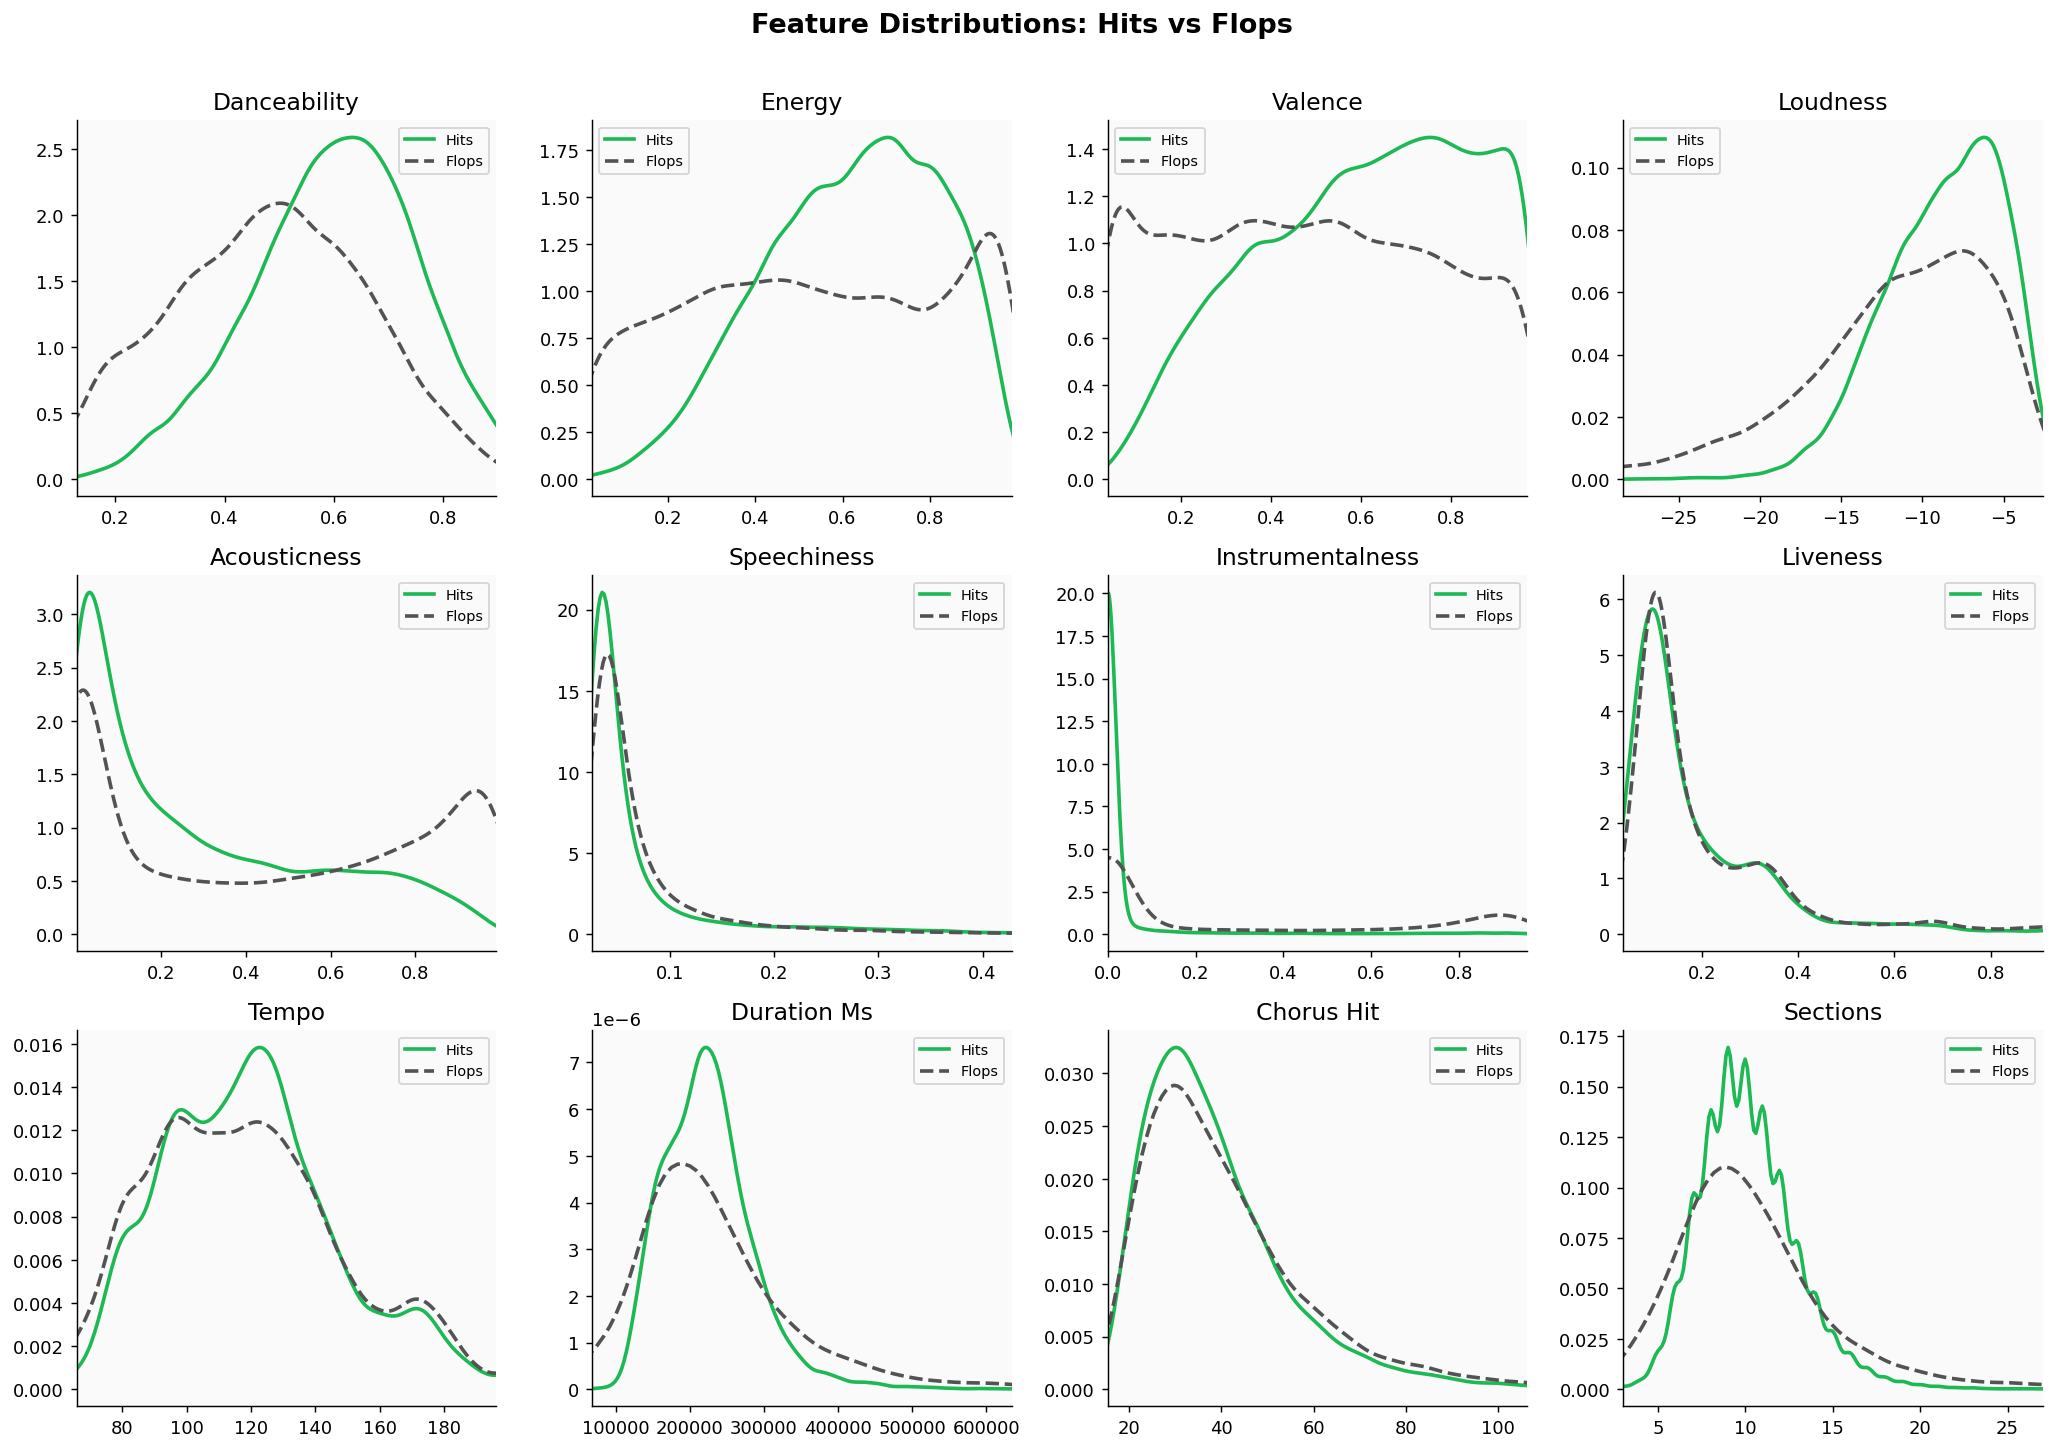

In [6]:
# ── KDE plots for all continuous features ─────────────────────────────────
FEATURES = ['danceability','energy','valence','loudness',
            'acousticness','speechiness','instrumentalness',
            'liveness','tempo','duration_ms','chorus_hit','sections']

hits  = df[df['is_hit'] == 1]
flops = df[df['is_hit'] == 0]

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    hits[feat].plot.kde(ax=ax, color=HIT_COLOR,  label='Hits',  lw=2)
    flops[feat].plot.kde(ax=ax, color=FLOP_COLOR, label='Flops', lw=2, linestyle='--')
    ax.set_title(feat.replace('_',' ').title())
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.legend(fontsize=8)
    # Shade the difference area
    ax.set_xlim(left=df[feat].quantile(0.01), right=df[feat].quantile(0.99))

plt.suptitle('Feature Distributions: Hits vs Flops', fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/02_feature_distributions.png', bbox_inches='tight')
plt.show()

In [7]:
# ── Mean comparison table: Hits vs Flops ─────────────────────────────────
comparison = df.groupby('is_hit')[FEATURES].mean().T
comparison.columns = ['Flops (0)', 'Hits (1)']
comparison['Difference'] = comparison['Hits (1)'] - comparison['Flops (0)']
comparison['% Change']   = (comparison['Difference'] / comparison['Flops (0)'].abs() * 100).round(1)
comparison = comparison.sort_values('Difference', ascending=False)

print('=== Mean Feature Values: Hits vs Flops ===')
print(comparison.round(4).to_string())

=== Mean Feature Values: Hits vs Flops ===
                    Flops (0)     Hits (1)  Difference  % Change
loudness             -11.7408      -8.7022      3.0386      25.9
tempo                118.3882     120.2883      1.9001       1.6
valence                0.4753       0.6096      0.1343      28.3
danceability           0.4782       0.6012      0.1231      25.7
energy                 0.5348       0.6243      0.0895      16.7
speechiness            0.0765       0.0694     -0.0070      -9.2
liveness               0.2104       0.1926     -0.0178      -8.5
acousticness           0.4476       0.2808     -0.1668     -37.3
instrumentalness       0.2781       0.0307     -0.2475     -89.0
sections              10.7680      10.1834     -0.5846      -5.4
chorus_hit            40.9880      39.2240     -1.7640      -4.3
duration_ms       243659.5609  226095.5400 -17564.0210      -7.2


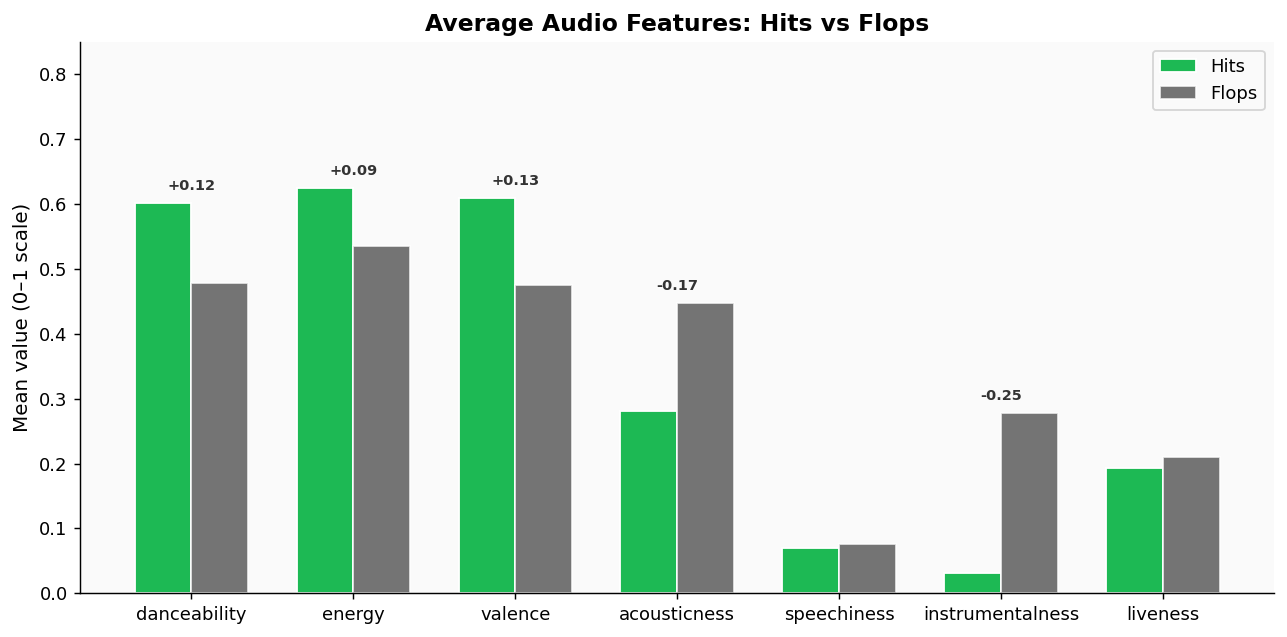

In [8]:
# ── Visual: Which features most separate hits from flops? ─────────────────
norm_feats = ['danceability','energy','valence','acousticness',
              'speechiness','instrumentalness','liveness']

means = df.groupby('is_hit')[norm_feats].mean()

fig, ax = plt.subplots(figsize=(10, 5))

x     = np.arange(len(norm_feats))
width = 0.35
bars1 = ax.bar(x - width/2, means.loc[1], width, label='Hits',
               color=HIT_COLOR,  edgecolor='white')
bars2 = ax.bar(x + width/2, means.loc[0], width, label='Flops',
               color=FLOP_COLOR, edgecolor='white', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([f.replace('_','\n') for f in norm_feats], fontsize=10)
ax.set_ylabel('Mean value (0–1 scale)')
ax.set_title('Average Audio Features: Hits vs Flops', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 0.85)

# Annotate the biggest gaps
for bar1, bar2 in zip(bars1, bars2):
    diff = bar1.get_height() - bar2.get_height()
    if abs(diff) > 0.05:
        mid_x = (bar1.get_x() + bar2.get_x() + bar2.get_width()) / 2
        mid_y = max(bar1.get_height(), bar2.get_height()) + 0.02
        ax.text(mid_x, mid_y, f'{diff:+.2f}', ha='center',
                fontsize=8, color='#333', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUTS}/03_feature_means_comparison.png', bbox_inches='tight')
plt.show()

## 5. Decade-by-Decade Trend Analysis

This is the most compelling section for your portfolio — showing how the "hit formula" has evolved.

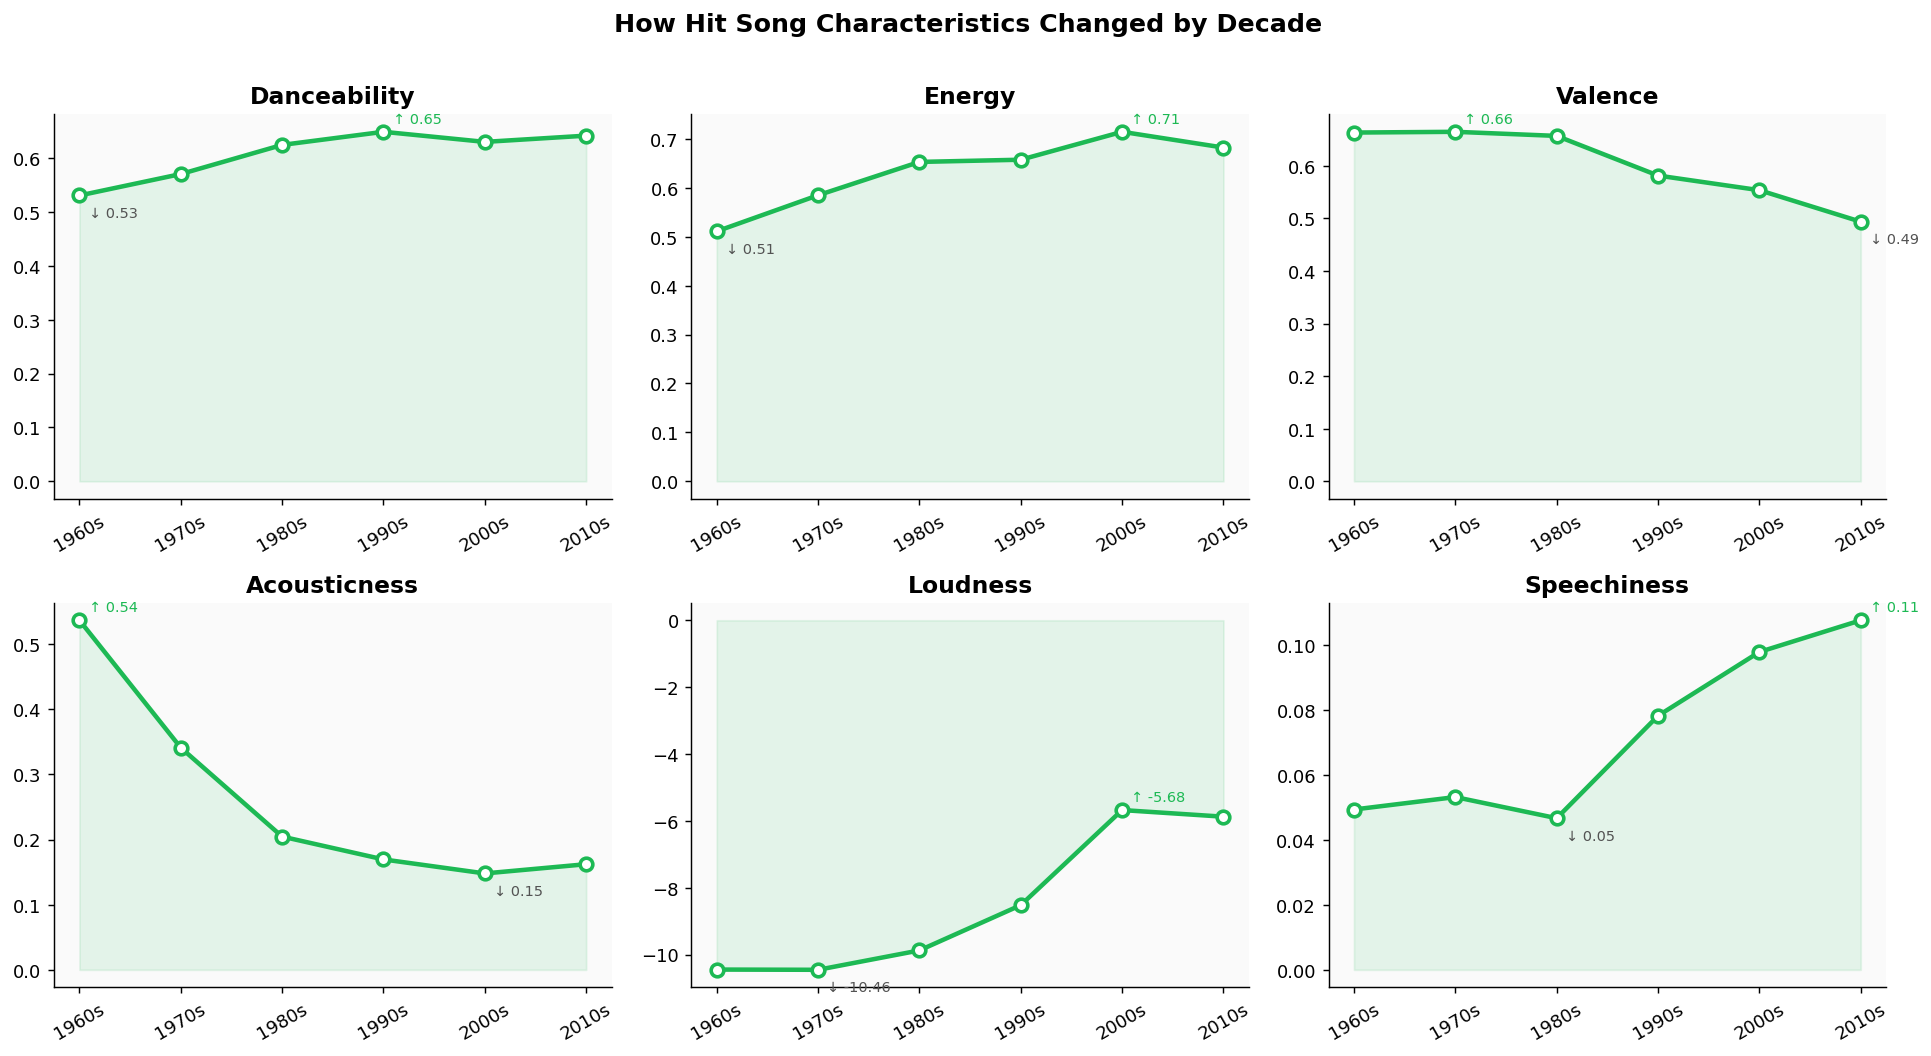

In [9]:
# ── How have hit song features changed over decades? ──────────────────────
trend_features = ['danceability','energy','valence','acousticness',
                  'loudness','speechiness']

decade_hits = df[df['is_hit']==1].groupby('decade')[trend_features].mean()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
decades_labels = [f"{d}s" for d in decade_hits.index]

for i, feat in enumerate(trend_features):
    ax = axes[i]
    vals = decade_hits[feat]
    ax.plot(range(len(vals)), vals, color=HIT_COLOR, lw=2.5,
            marker='o', markersize=7, markerfacecolor='white',
            markeredgecolor=HIT_COLOR, markeredgewidth=2)
    ax.fill_between(range(len(vals)), vals, alpha=0.1, color=HIT_COLOR)
    ax.set_title(feat.replace('_',' ').title(), fontweight='bold')
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(decades_labels, rotation=30)
    # Annotate min and max
    ax.annotate(f'↑ {vals.max():.2f}', xy=(vals.argmax(), vals.max()),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, color=HIT_COLOR)
    ax.annotate(f'↓ {vals.min():.2f}', xy=(vals.argmin(), vals.min()),
                xytext=(5, -12), textcoords='offset points',
                fontsize=8, color=FLOP_COLOR)

plt.suptitle('How Hit Song Characteristics Changed by Decade',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/04_decade_trends.png', bbox_inches='tight')
plt.show()

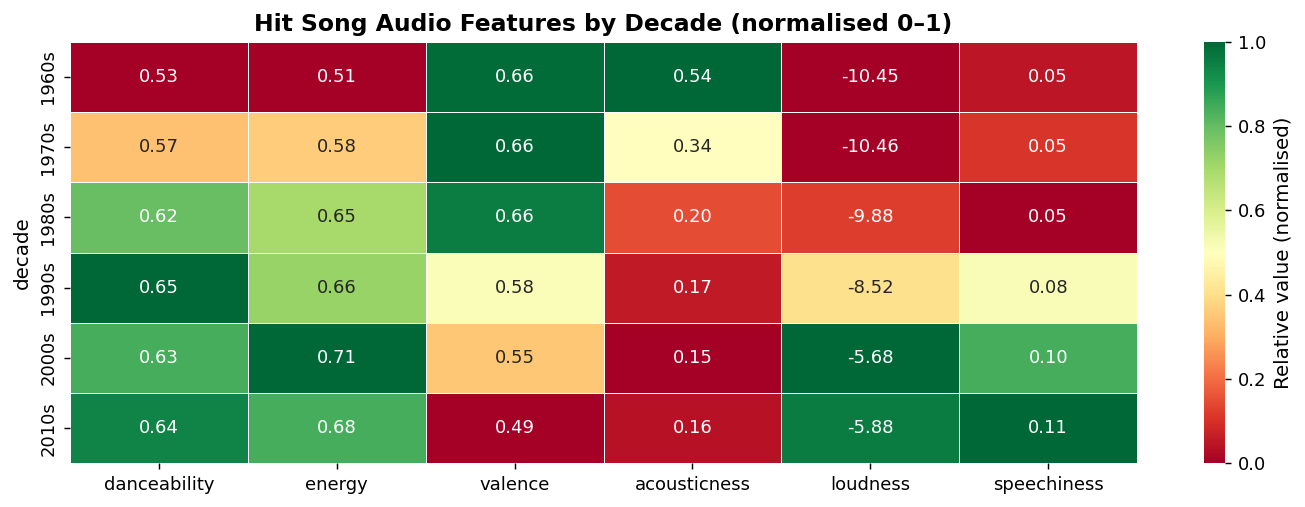

In [10]:
# ── Heatmap: feature values for HITS across all decades ───────────────────
# Normalize each feature to 0-1 for fair comparison across columns
norm = (decade_hits - decade_hits.min()) / (decade_hits.max() - decade_hits.min())

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    norm,
    ax=ax,
    cmap='RdYlGn',
    annot=decade_hits.round(2),
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Relative value (normalised)'},
    yticklabels=decades_labels
)
ax.set_title('Hit Song Audio Features by Decade (normalised 0–1)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/05_decade_heatmap.png', bbox_inches='tight')
plt.show()

## 6. Correlation Analysis

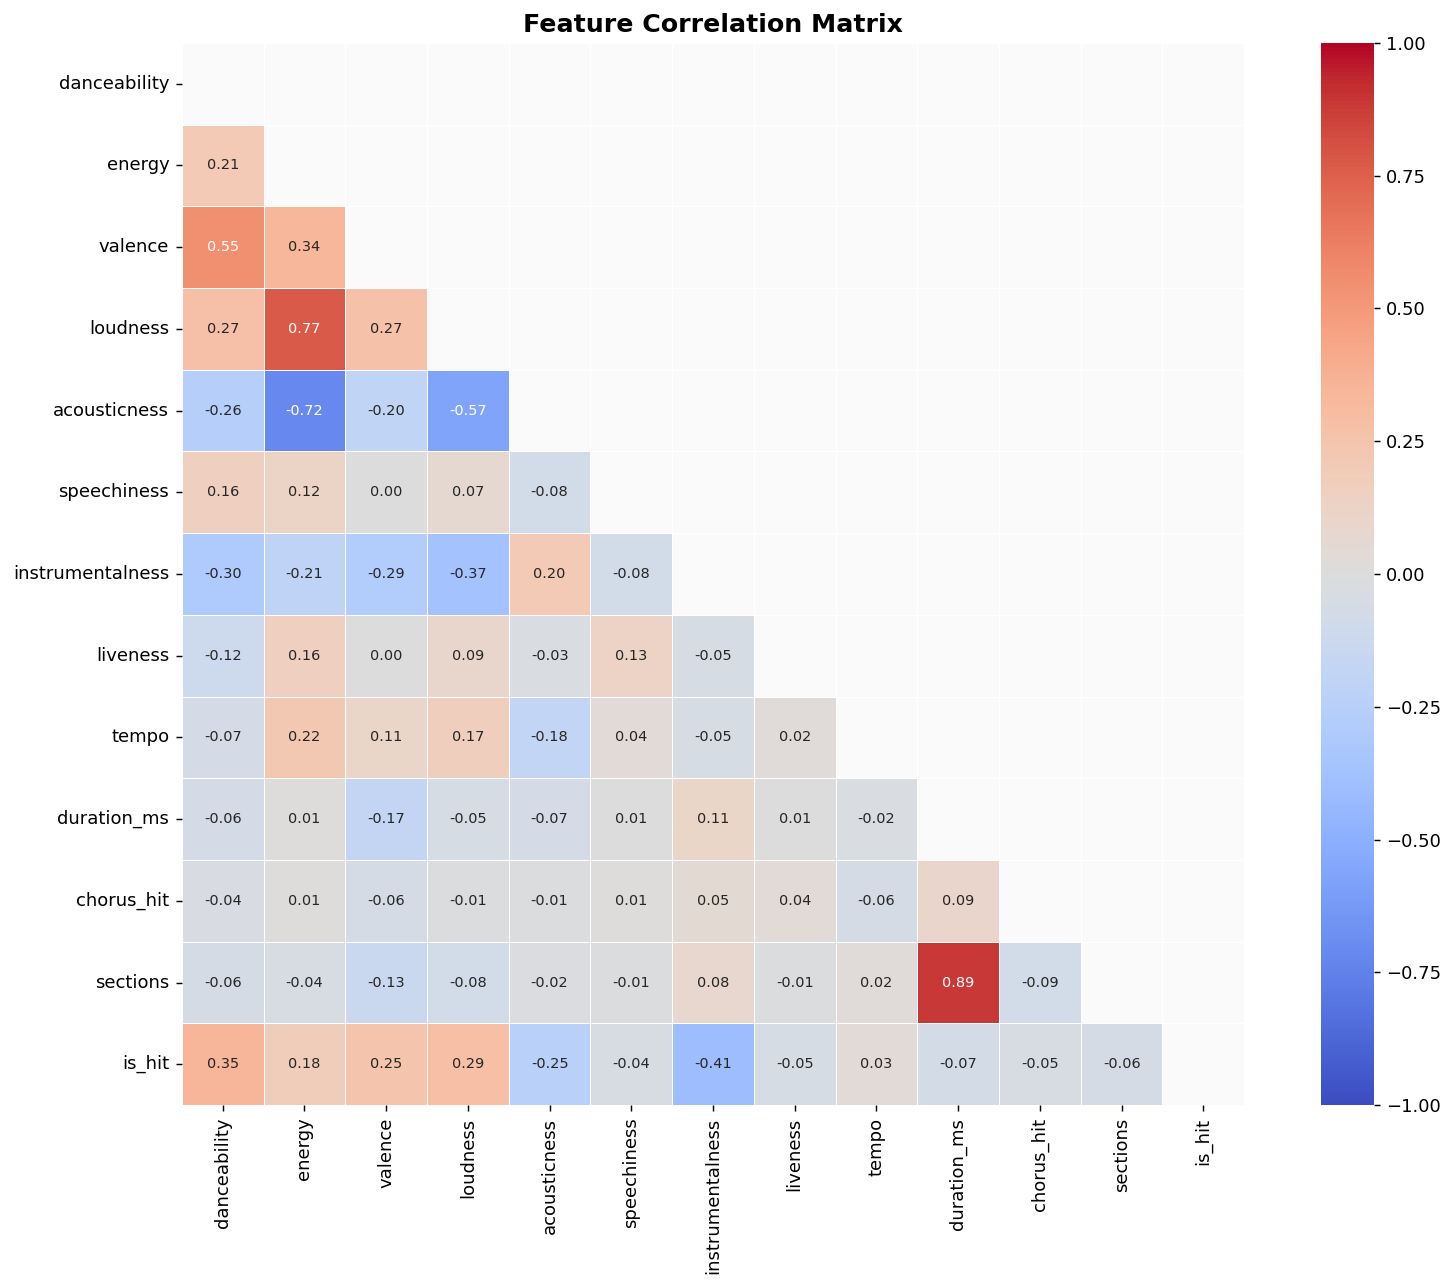

In [11]:
# ── Full correlation matrix ────────────────────────────────────────────────
corr_features = FEATURES + ['is_hit']
corr_matrix   = df[corr_features].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    ax=ax,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8},
    linewidths=0.4,
    square=True,
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/06_correlation_matrix.png', bbox_inches='tight')
plt.show()

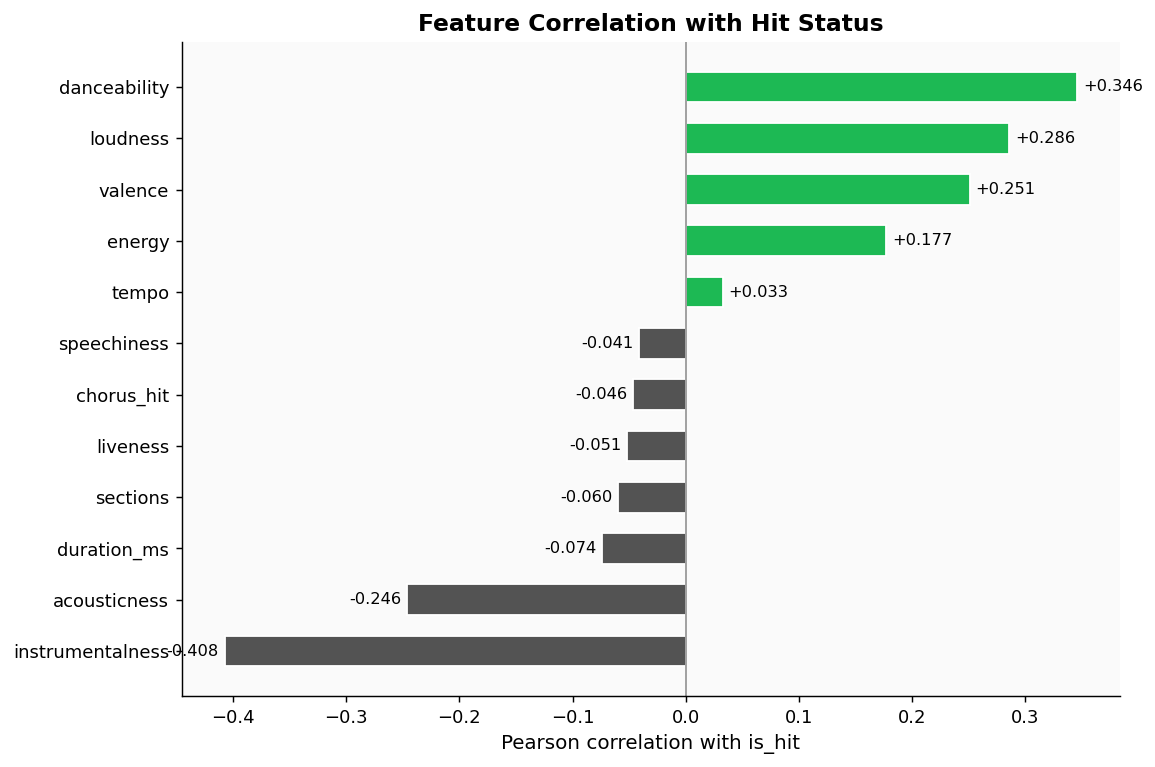


Top positive correlators with hits:
danceability    0.346097
loudness        0.286034
valence         0.251147
energy          0.177142
tempo           0.032649
Name: is_hit, dtype: float64

Top negative correlators (more = less likely hit):
instrumentalness   -0.407638
acousticness       -0.246036
duration_ms        -0.073820
sections           -0.059997
liveness           -0.051445
Name: is_hit, dtype: float64


In [12]:
# ── Which features correlate most with is_hit? ────────────────────────────
target_corr = corr_matrix['is_hit'].drop('is_hit').sort_values()

colors = [HIT_COLOR if v > 0 else FLOP_COLOR for v in target_corr]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(target_corr.index, target_corr.values,
               color=colors, edgecolor='white', height=0.6)
ax.axvline(0, color='#999', lw=1)
ax.set_xlabel('Pearson correlation with is_hit')
ax.set_title('Feature Correlation with Hit Status',
             fontsize=13, fontweight='bold')

for bar, val in zip(bars, target_corr.values):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}',
            va='center', ha='left' if val >= 0 else 'right',
            fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUTS}/07_target_correlation.png', bbox_inches='tight')
plt.show()

print('\nTop positive correlators with hits:')
print(target_corr[target_corr > 0].sort_values(ascending=False).head())
print('\nTop negative correlators (more = less likely hit):')
print(target_corr[target_corr < 0].sort_values().head())

## 7. The Hit Formula — Radar Chart

A radar chart showing the average profile of a hit vs a flop — great for your portfolio and LinkedIn post.

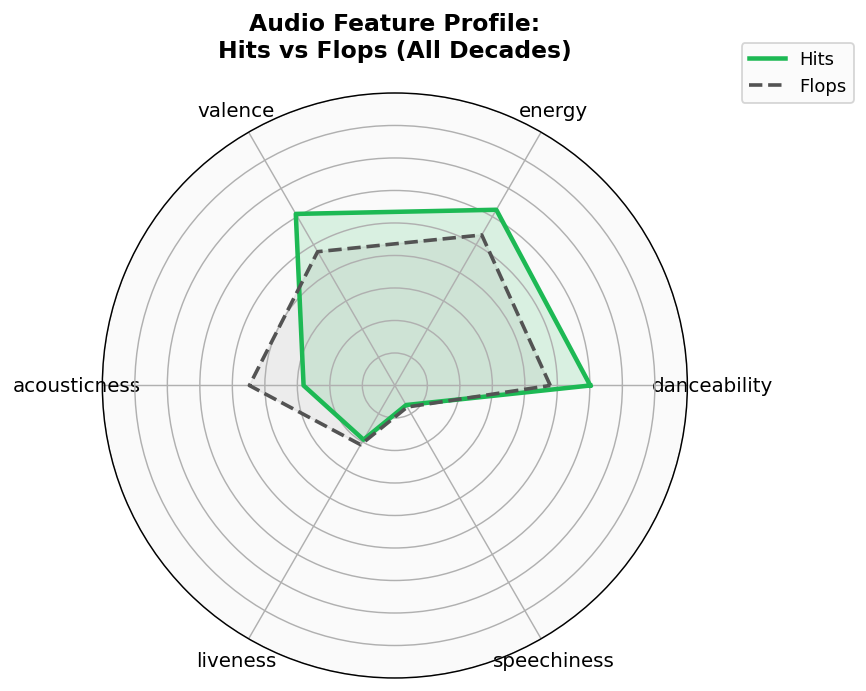

In [13]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

radar_features = ['danceability','energy','valence',
                  'acousticness','liveness','speechiness']

hit_means  = df[df['is_hit']==1][radar_features].mean().values
flop_means = df[df['is_hit']==0][radar_features].mean().values

N      = len(radar_features)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()

# Close the circle
hit_means  = np.append(hit_means,  hit_means[0])
flop_means = np.append(flop_means, flop_means[0])
angles     = angles + angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

ax.plot(angles, hit_means,  color=HIT_COLOR,  lw=2.5, label='Hits')
ax.fill(angles, hit_means,  color=HIT_COLOR,  alpha=0.15)
ax.plot(angles, flop_means, color=FLOP_COLOR, lw=2,   label='Flops', linestyle='--')
ax.fill(angles, flop_means, color=FLOP_COLOR, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, size=11)
ax.set_ylim(0, 0.9)
ax.set_yticklabels([])
ax.set_title('Audio Feature Profile:\nHits vs Flops (All Decades)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig(f'{OUTPUTS}/08_radar_chart.png', bbox_inches='tight')
plt.show()

## 8. Deep Dive — Interesting Findings

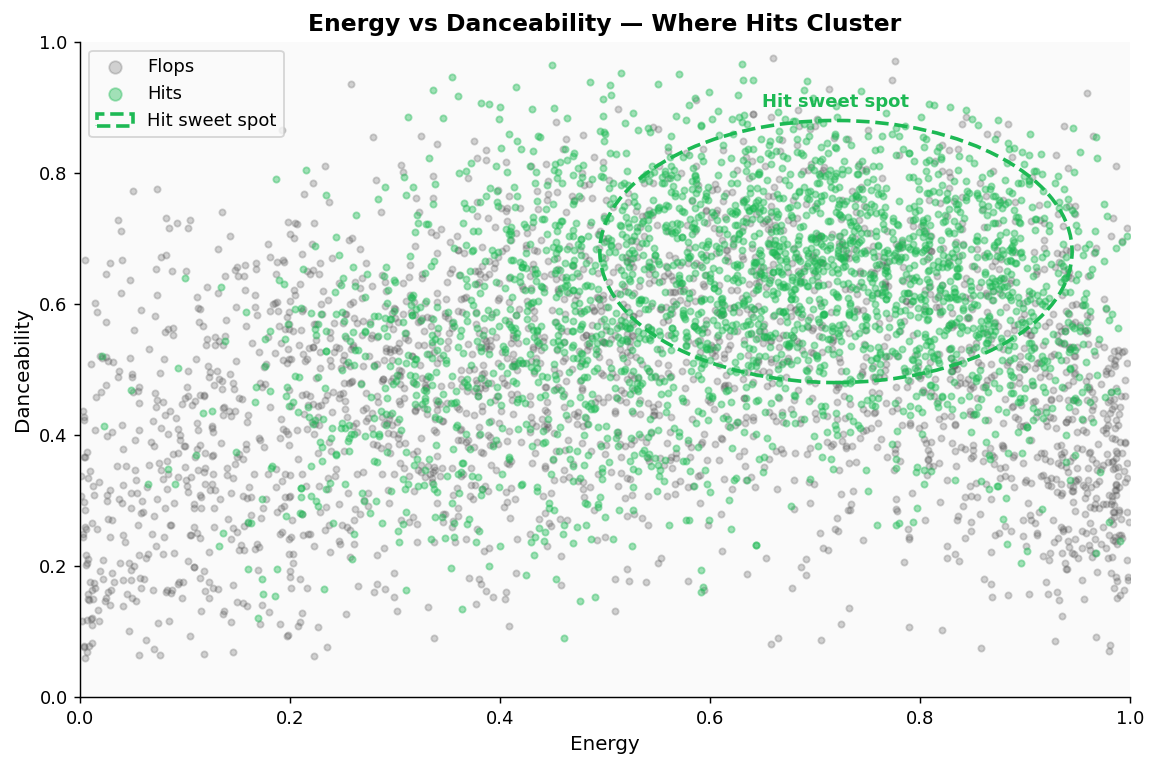

In [14]:
# ── Finding 1: Energy × Danceability scatter — hit zone ───────────────────
fig, ax = plt.subplots(figsize=(9, 6))

sample = df.sample(5000, random_state=42)  # sample for speed
flop_s = sample[sample['is_hit']==0]
hit_s  = sample[sample['is_hit']==1]

ax.scatter(flop_s['energy'], flop_s['danceability'],
           color=FLOP_COLOR, alpha=0.25, s=12, label='Flops')
ax.scatter(hit_s['energy'],  hit_s['danceability'],
           color=HIT_COLOR,  alpha=0.4,  s=12, label='Hits')

# Draw the "sweet spot" ellipse
from matplotlib.patches import Ellipse
ellipse = Ellipse(xy=(0.72, 0.68), width=0.45, height=0.40,
                  edgecolor=HIT_COLOR, facecolor='none',
                  lw=2, linestyle='--', label='Hit sweet spot')
ax.add_patch(ellipse)
ax.text(0.72, 0.90, 'Hit sweet spot', ha='center',
        color=HIT_COLOR, fontsize=10, fontweight='bold')

ax.set_xlabel('Energy', fontsize=11)
ax.set_ylabel('Danceability', fontsize=11)
ax.set_title('Energy vs Danceability — Where Hits Cluster',
             fontsize=13, fontweight='bold')
ax.legend(markerscale=2)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(f'{OUTPUTS}/09_energy_danceability_scatter.png', bbox_inches='tight')
plt.show()

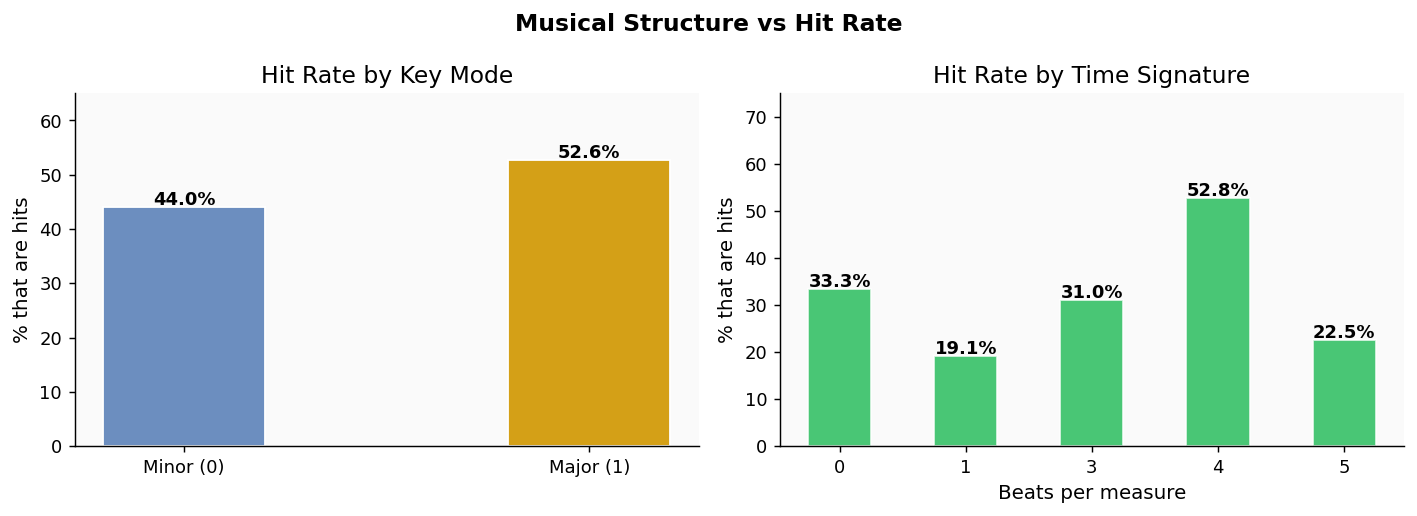

In [15]:
# ── Finding 2: Do major key songs chart more? ─────────────────────────────
mode_hit_rate = df.groupby('mode')['is_hit'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Mode (major vs minor)
axes[0].bar(['Minor (0)', 'Major (1)'], mode_hit_rate.values,
            color=['#6c8ebf','#d4a017'], width=0.4, edgecolor='white')
for i, v in enumerate(mode_hit_rate.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Hit Rate by Key Mode')
axes[0].set_ylabel('% that are hits')
axes[0].set_ylim(0, 65)

# Time signature
ts_hit_rate = df.groupby('time_signature')['is_hit'].mean() * 100
axes[1].bar(ts_hit_rate.index.astype(str), ts_hit_rate.values,
            color=HIT_COLOR, alpha=0.8, width=0.5, edgecolor='white')
for i, (idx, v) in enumerate(ts_hit_rate.items()):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Hit Rate by Time Signature')
axes[1].set_xlabel('Beats per measure')
axes[1].set_ylabel('% that are hits')
axes[1].set_ylim(0, 75)

plt.suptitle('Musical Structure vs Hit Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/10_mode_timesig.png', bbox_inches='tight')
plt.show()

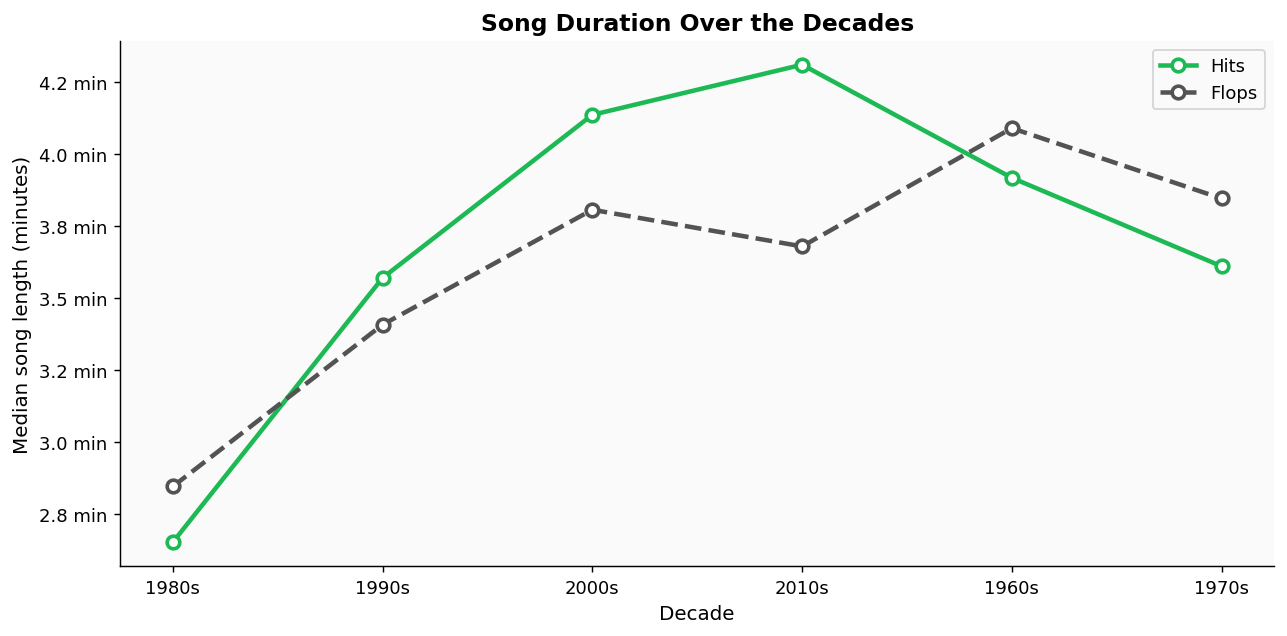

In [16]:
# ── Finding 3: Song duration over the decades ──────────────────────────────
df['duration_min'] = df['duration_ms'] / 60000

fig, ax = plt.subplots(figsize=(10, 5))

for label, subset, color, ls in [
    ('Hits',  df[df['is_hit']==1], HIT_COLOR,  '-'),
    ('Flops', df[df['is_hit']==0], FLOP_COLOR, '--'),
]:
    decade_dur = subset.groupby('decade')['duration_min'].median()
    ax.plot(decade_dur.index, decade_dur.values,
            color=color, lw=2.5, marker='o', markersize=7,
            markerfacecolor='white', markeredgewidth=2,
            linestyle=ls, label=label)

ax.set_xlabel('Decade')
ax.set_ylabel('Median song length (minutes)')
ax.set_title('Song Duration Over the Decades', fontsize=13, fontweight='bold')
ax.set_xticks(df['decade'].unique())
ax.set_xticklabels([f"{d}s" for d in sorted(df['decade'].unique())])
ax.legend()
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f min'))

plt.tight_layout()
plt.savefig(f'{OUTPUTS}/11_duration_trends.png', bbox_inches='tight')
plt.show()

## 9. EDA Summary & Key Takeaways

In [17]:
# ── Print a clean summary of findings ─────────────────────────────────────
print('=' * 60)
print('  EDA SUMMARY — Spotify Hit Predictor')
print('=' * 60)

print(f'''
📊 DATASET
   Total songs:    {len(df):,}
   Hits:           {df['is_hit'].sum():,} ({df['is_hit'].mean()*100:.1f}%)
   Flops:          {(df['is_hit']==0).sum():,} ({(1-df['is_hit'].mean())*100:.1f}%)
   Decades:        1960s – 2010s
   Missing values: None ✅

🎵 HITS HAVE MORE:
   + Danceability  (avg {hits['danceability'].mean():.2f} vs {flops['danceability'].mean():.2f} for flops)
   + Energy        (avg {hits['energy'].mean():.2f} vs {flops['energy'].mean():.2f})
   + Loudness      (avg {hits['loudness'].mean():.1f}dB vs {flops['loudness'].mean():.1f}dB)

🔇 HITS HAVE LESS:
   - Acousticness  (avg {hits['acousticness'].mean():.2f} vs {flops['acousticness'].mean():.2f})
   - Instrumentalness (hits are vocal; flops often instrumental)

📅 DECADE TRENDS:
   - Energy ↑ sharply from 1960s to 2000s
   - Acousticness ↓ dramatically over decades
   - Valence (happiness) has declined since 1980s
   - Songs have gotten shorter since the 1970s peak

🎯 MOST PREDICTIVE FEATURES (from correlation):
''')

top_pos = target_corr[target_corr > 0].sort_values(ascending=False).head(3)
top_neg = target_corr[target_corr < 0].sort_values().head(3)
for feat, val in top_pos.items():
    print(f'   + {feat:<22} r = {val:+.3f}')
for feat, val in top_neg.items():
    print(f'   - {feat:<22} r = {val:+.3f}')

print(f'''
✅ READY FOR PHASE 3:
   Dataset saved → data/master_dataset.csv
   Figures saved → outputs/figures/
   Next: 03_modelling.ipynb — build the hit predictor model
''')

# Save the cleaned dataset
df.to_csv('../data/master_dataset.csv', index=False)
print(f'💾  Saved master_dataset.csv ({len(df):,} rows)')

  EDA SUMMARY — Spotify Hit Predictor

📊 DATASET
   Total songs:    41,106
   Hits:           20,553 (50.0%)
   Flops:          20,553 (50.0%)
   Decades:        1960s – 2010s
   Missing values: None ✅

🎵 HITS HAVE MORE:
   + Danceability  (avg 0.60 vs 0.48 for flops)
   + Energy        (avg 0.62 vs 0.53)
   + Loudness      (avg -8.7dB vs -11.7dB)

🔇 HITS HAVE LESS:
   - Acousticness  (avg 0.28 vs 0.45)
   - Instrumentalness (hits are vocal; flops often instrumental)

📅 DECADE TRENDS:
   - Energy ↑ sharply from 1960s to 2000s
   - Acousticness ↓ dramatically over decades
   - Valence (happiness) has declined since 1980s
   - Songs have gotten shorter since the 1970s peak

🎯 MOST PREDICTIVE FEATURES (from correlation):

   + danceability           r = +0.346
   + loudness               r = +0.286
   + valence                r = +0.251
   - instrumentalness       r = -0.408
   - acousticness           r = -0.246
   - duration_ms            r = -0.074

✅ READY FOR PHASE 3:
   Dataset save

---
## Next Steps → Phase 3: Modelling

Open `03_modelling.ipynb` to:
- Build a Logistic Regression baseline
- Train a Random Forest model  
- Tune an XGBoost classifier
- Generate a feature importance chart
- Evaluate with ROC-AUC, precision, recall